In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

In [2]:
# To sort through the folders and files
basepath = Path('./data/') # where the folders are
#empty lists
dataList=[] 
foldernames=[]

#Will read all the .sig files from the spectrometer and add the data to a large list
datafolders = sorted([item for item in basepath.iterdir() if item.is_dir() and not item.name.startswith('.')]) #List of all directories (folders) in the location, excluding hiddens folders
for datafolder in datafolders:
    datafiles = [file for file in sorted(datafolder.iterdir()) if file.suffix=='.sig'] #variable will be everyfile in the folder with .sig suffix
    foldernames.append(datafolder.name)
    for i, datafile in enumerate(datafiles):
        data = pd.read_table(datafile,skiprows=26,sep='  ',engine='python') #reading the file & setting it's contents to a dataframe
        data = data.reset_index() #resetting the dataframe's index
        data.columns = ['Wavelength (nm)','Ref Radiance','Target Radience','Target Reflectance'] #setting column names
        data['foldername'] = datafolder.name #adding a column with the folder name
        data['filename'] = datafile.name #adding another column with the files name
        dataList.append(data) #adding dataframe to a list

#taking the list and turning it into a dataframe and then saving it to a file
data_all = pd.concat(dataList).reset_index(drop=True) 
data_all.to_csv('data_all.csv')

In [3]:
#creating a separate dataframe with the average for each sample type

avg_specs = []#empty list
wavelengths = data_all['Wavelength (nm)'].unique() #Creates a list of all of the unqiue values found in Wavelengths
for i,foldername in enumerate(foldernames):
    wavelength_mean_refl_list=[] #empty list (used later)
    for wavelength in wavelengths:
        wavelength_mean_refl = data_all[(data_all['Wavelength (nm)'] == wavelength) & (data_all['foldername'] == foldername)]['Target Reflectance'].mean() #taking the average across all the measurements for that sample
        wavelength_mean_refl_list.append(wavelength_mean_refl)
    avg = pd.DataFrame([wavelengths, wavelength_mean_refl_list]).T #making a dataframe with the wavelengths and the avg reflectance for each wavelength (does this for every folder)
    avg['foldername'] = foldername #adds a column that is the foldername the spec came from
    avg_specs.append(avg) #appends the average spectrum to a list
avgspecs = pd.concat(avg_specs).reset_index(drop=True) #resetting the index and converting list to dataframe, wont add another column of previous index
avgspecs.to_csv('Average_Spectra.csv')

In [2]:
#quick way to access the files for all measurments
data_all = pd.read_csv('./data_all.csv')
del data_all['Unnamed: 0']
data_all

,Wavelength (nm),Ref Radiance,Target Radience,Target Reflectance,foldername,filename
0,339.3,406.41,117.99,29.03,bent005ck,gr063026_0044.sig
1,340.8,434.01,123.40,28.43,bent005ck,gr063026_0044.sig
2,342.3,466.55,130.96,28.07,bent005ck,gr063026_0044.sig
3,343.7,494.38,134.47,27.20,bent005ck,gr063026_0044.sig
4,345.2,530.95,151.70,28.57,bent005ck,gr063026_0044.sig
...,...,...,...,...,...,...
303165,2504.7,13035.65,5287.04,40.56,kao5ppfr,gr070226_0069.sig
303166,2506.7,13037.53,5291.66,40.59,kao5ppfr,gr070226_0069.sig
303167,2508.8,13006.28,5279.78,40.59,kao5ppfr,gr070226_0069.sig
303168,2510.9,13064.63,5299.88,40.57,kao5ppfr,gr070226_0069.sig


In [3]:
#quick way to access the files for the average of each sample type
avgspecs = pd.read_csv('./Average_Spectra.csv')
del avgspecs['Unnamed: 0']
avgspecs.rename(columns={'0': 'Wavelength (nm)','1': 'Target Reflectance'}, inplace=True)
avgspecs

,Wavelength (nm),Target Reflectance,foldername
0,339.3,27.1465,bent005ck
1,340.8,26.8220,bent005ck
2,342.3,26.1780,bent005ck
3,343.7,25.4310,bent005ck
4,345.2,24.9400,bent005ck
...,...,...,...
15899,2504.7,37.0395,kao5ppfr
15900,2506.7,37.0380,kao5ppfr
15901,2508.8,37.0480,kao5ppfr
15902,2510.9,37.0460,kao5ppfr


In [7]:

foldernames

115304    bent5ppfm
115305    bent5ppfm
115306    bent5ppfm
115307    bent5ppfm
115308    bent5ppfm
            ...    
135179    bent5ppfm
135180    bent5ppfm
135181    bent5ppfm
135182    bent5ppfm
135183    bent5ppfm
Name: foldername, Length: 19880, dtype: object

In [9]:
#Will create multiple figures, 1 for each folder, has all spectra in grey and the avg spectra in blue

fig, ax = plt.subplots(len(foldernames),1,figsize=(23,5*len(foldernames)),sharex=True,sharey=True) #figure parameters and size

#Labeling the axes and title
ax[-1].set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax[0].set_title('Spectra of control kaolinite with 0.05% alfalfa meal soil sample')

#plots every single measurement, based on sample type, and the average of each sample
wavelengths = data_all['Wavelength (nm)'].unique() #Creates a list of all of the unqiue values found in Wavelengths
foldernames = data_all['foldername'].unique()
for i,foldername in enumerate(foldernames):
    plotting = data_all[data_all['foldername']==foldername]['filename'].unique()
    for file in plotting:
        data_to_plot = data_all[data_all['filename']==file] 
        ax[i].plot(data_to_plot['Wavelength (nm)'],data_to_plot['Target Reflectance'],color='grey')
    ax[i].plot(avgspecs[avgspecs['foldername']==foldername]['Wavelength (nm)'],avgspecs[avgspecs['foldername']==foldername]['Target Reflectance'],label=foldername,color='Blue')
    ax[i].legend(loc=2)
    ax[i].set_xlim(340,2500)#(1000,1500)
    ax[i].set_ylim(0,100)
plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f8497b36ac0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Image size of 2300x9940000 pixels is too large. It must be less than 2^23 in each direction.

ValueError: Image size of 2300x9940000 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 2300x9.94e+06 with 3684 Axes>

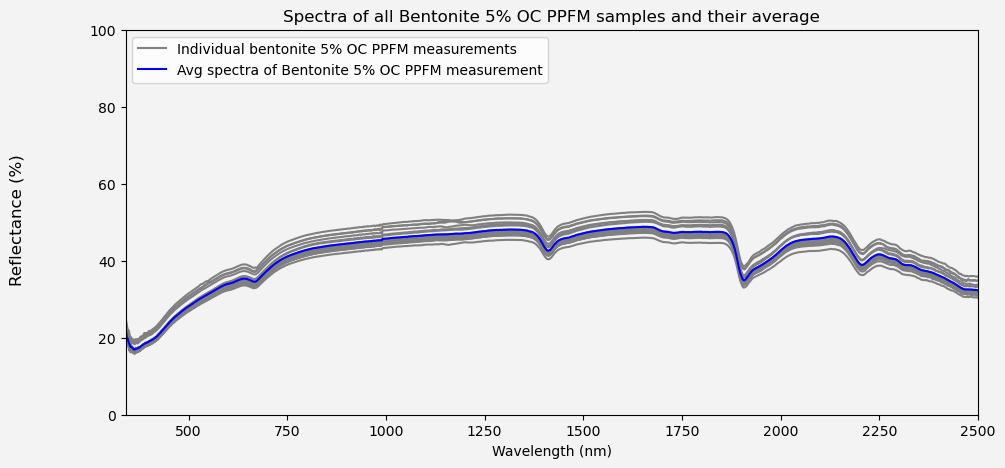

In [20]:
#Will create multiple figures, 1 for each folder, has all spectra in grey and the avg spectra in blue

fig, ax = plt.subplots(1,1,figsize=(11,5),sharex=True,sharey=True) #figure parameters and size

#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of all Bentonite 5% OC PPFM samples and their average')

#plots every single measurement, based on sample type, and the average of each sample
wavelengths = data_all['Wavelength (nm)'].unique() #Creates a list of all of the unqiue values found in Wavelengths
plotting = data_all[data_all['foldername']=='bent5ppfm']['filename'].unique()
for file in plotting:
    data_to_plot = data_all[data_all['filename']==file] 
    ax.plot(data_to_plot['Wavelength (nm)'],data_to_plot['Target Reflectance'],color='grey')
ax.plot(avgspecs[avgspecs['foldername']=='bent5ppfm']['Wavelength (nm)'],avgspecs[avgspecs['foldername']=='bent5ppfm']['Target Reflectance'],label='Individual bentonite 5% OC PPFM measurements',color='grey')
ax.plot(avgspecs[avgspecs['foldername']=='bent5ppfm']['Wavelength (nm)'],avgspecs[avgspecs['foldername']=='bent5ppfm']['Target Reflectance'],label='Avg spectra of Bentonite 5% OC PPFM measurement',color='Blue')
ax.legend(loc=2)
ax.set_xlim(340,2500)#(1000,1500)
ax.set_ylim(0,100)
ax.set_facecolor('#f3f3f3')  # changing the color of the axes
fig.set_facecolor('#f3f3f3')  # changing the color of the figure
plt.savefig('./Figures/Bent5PPFM_Avging.png')
plt.show()

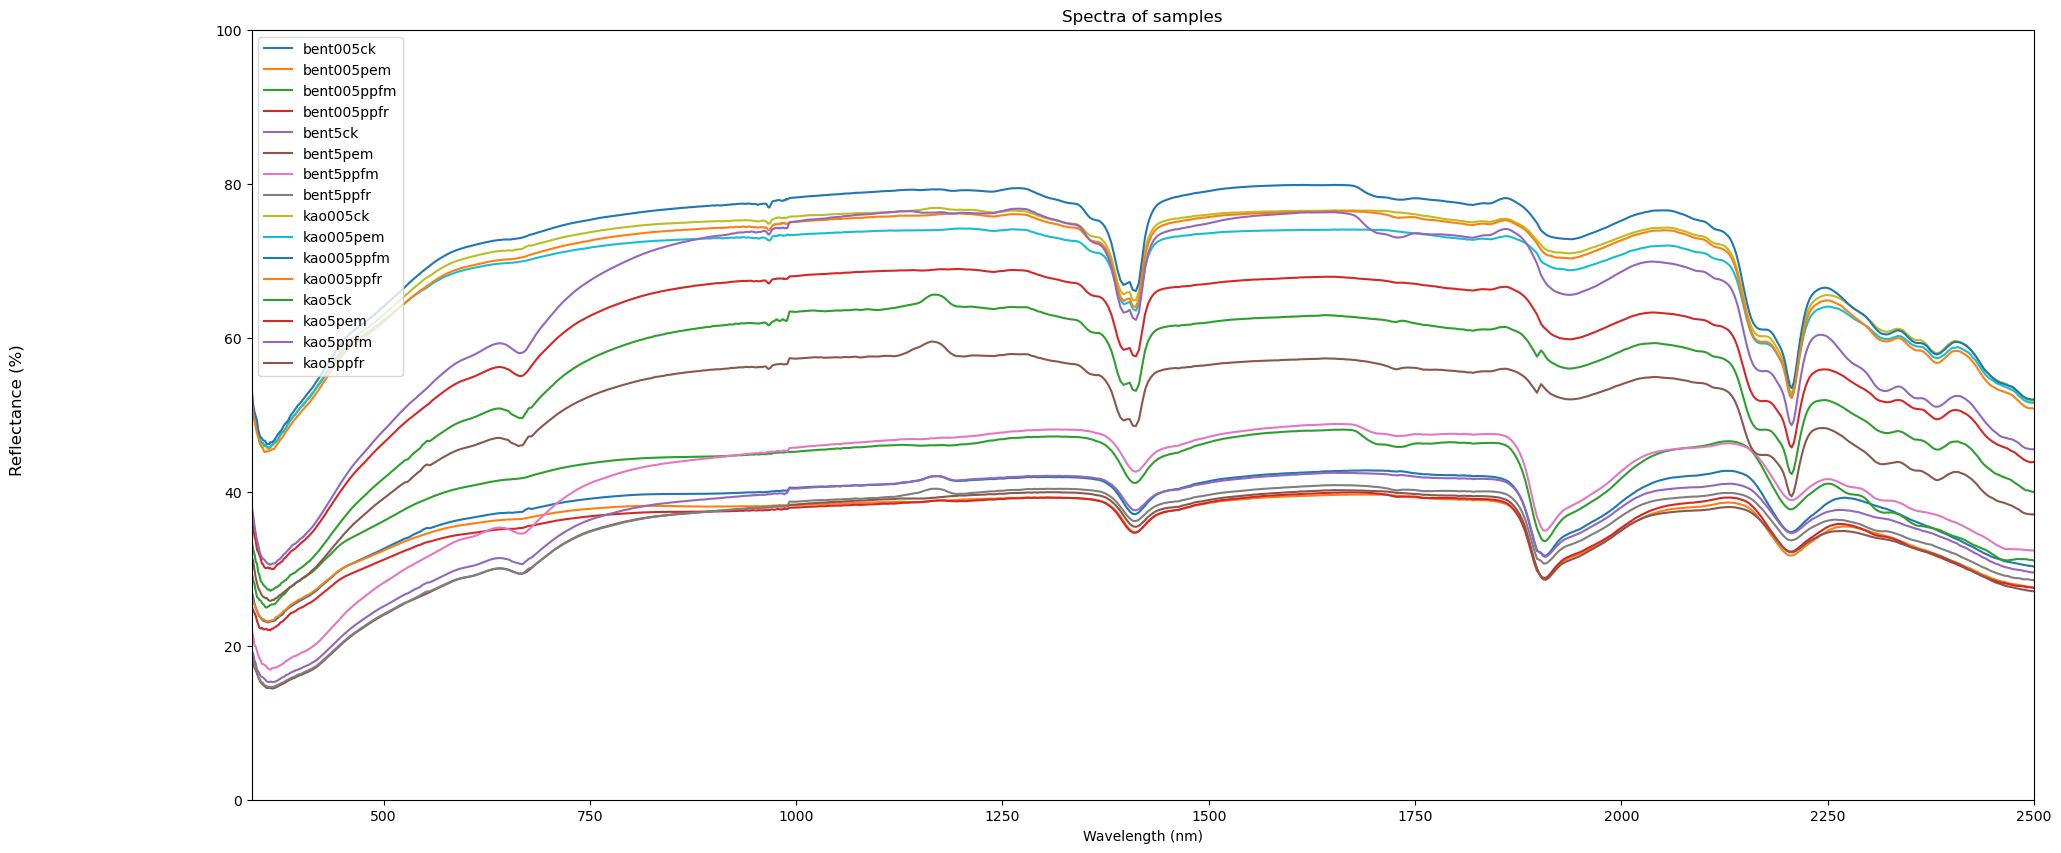

In [7]:
#Creates a figure with each of the avg spectra for each sample type

#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(23,10),sharex=True,sharey=True)

#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of samples')
ax.set_xlim(340,2500)#(1000,1500)
ax.set_ylim(0,100)

#plots the average of each sample type
foldernames = data_all['foldername'].unique()
for i,foldername in enumerate(foldernames):
    ax.plot(avgspecs[avgspecs['foldername']==foldername]['Wavelength (nm)'],avgspecs[avgspecs['foldername']==foldername]['Target Reflectance'],label=foldername) #plots each average spectrum vs the wavelength
ax.legend(loc=2)
# plt.savefig('./Figures/all_avg_spectra.png')
plt.show()

In [8]:
#Add the spectra with tears in the spectra near 1900 to this list 
#this can be done by adding '| (avgspecs['foldername'] == 'foldername')'
spectra_to_fix = avgspecs[(avgspecs['foldername'] == 'kao5ck') | (avgspecs['foldername'] == 'kao5ppfr')].reset_index(drop=True)
spectra_to_fix['foldername'].unique()

array(['kao5ck', 'kao5ppfr'], dtype=object)

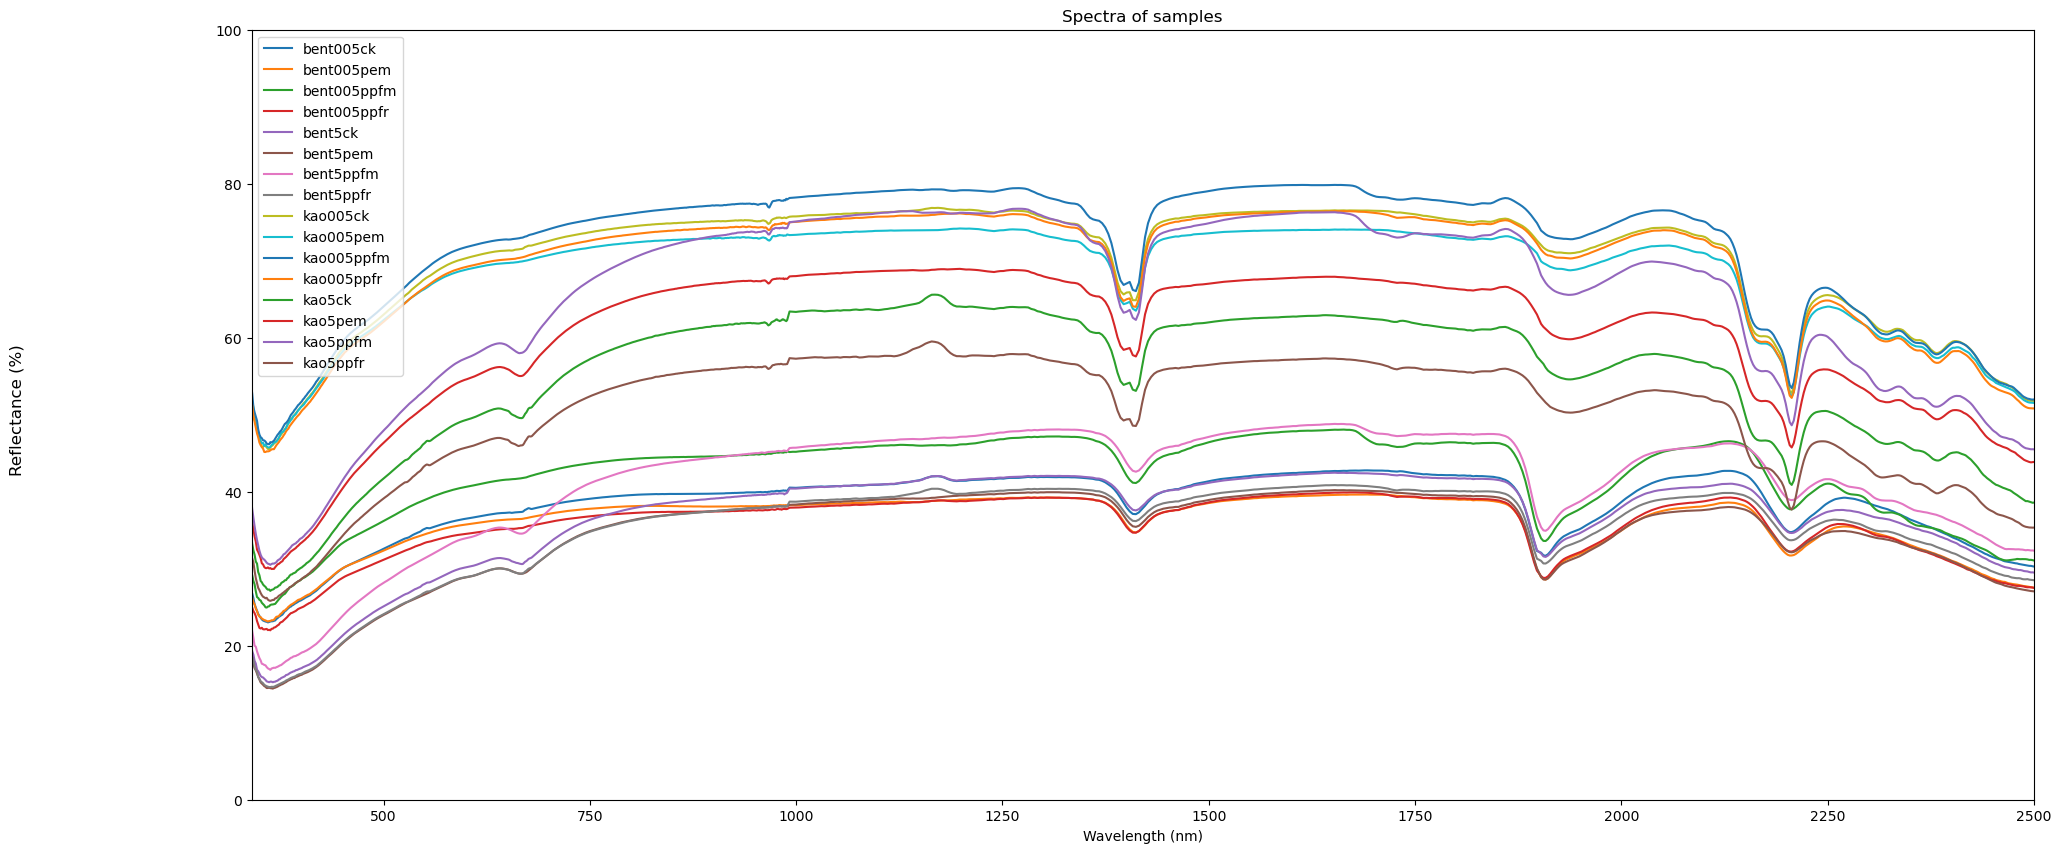

In [9]:
#This code will fix the spectra listed above, and then plot them

#to create the figure base
fig, ax = plt.subplots(1,1,figsize=(23,10),sharex=True,sharey=True)
#Labeling the axes and title
ax.set_xlabel('Wavelength (nm)')
fig.supylabel('Reflectance (%)')
ax.set_title('Spectra of samples')
ax.set_xlim(340,2500)#(1000,1500)
ax.set_ylim(0,100)

#fixing and plotting the spectra
for foldername in avgspecs['foldername'].unique():
    lir_diff = 0
    if foldername in spectra_to_fix['foldername'].unique():
        long_reflect = avgspecs[(avgspecs['Wavelength (nm)'] == 1902.7) & (avgspecs['foldername'] == foldername)]['Target Reflectance'].reset_index(drop=True)
        short_reflect = avgspecs[(avgspecs['Wavelength (nm)'] == 1897.7) & (avgspecs['foldername'] == foldername)]['Target Reflectance'].reset_index(drop=True)
        lir_diff = (long_reflect - short_reflect + 0.6).item()
        lir_wavelengths = avgspecs[avgspecs['Wavelength (nm)'] > 1900.0]['Wavelength (nm)'].unique()
        for waveleng in lir_wavelengths:
            avgspecs.loc[(avgspecs['Wavelength (nm)'] == waveleng) & (avgspecs['foldername'] == foldername),'Target Reflectance'] = avgspecs.loc[(avgspecs['Wavelength (nm)'] == waveleng) & (avgspecs['foldername'] == foldername),'Target Reflectance'] - lir_diff
    ax.plot(avgspecs[avgspecs['foldername']==foldername]['Wavelength (nm)'],avgspecs[avgspecs['foldername']==foldername]['Target Reflectance'],label=foldername)
ax.legend(loc=2)
plt.savefig('./Figures/kaotearfix.png')
plt.show()

In [10]:
#saving the fixed spectra
avgspecs.to_csv('Average_Spectra_fixed.csv')